In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [21]:
import warnings
warnings.filterwarnings('ignore')

In [22]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    return x

In [23]:
def build_unet(input_shape=(128, 128, 1)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = conv_block(p3, 256)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = conv_block(p4, 512)

    # Decoder
    u6 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = conv_block(u6, 256)

    u7 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = conv_block(u7, 128)

    u8 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = conv_block(u8, 64)

    u9 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = conv_block(u9, 32)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = models.Model(inputs=[inputs], outputs=[outputs], name="OilSpill_Segmentation")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

In [24]:
detection_model = build_unet(input_shape=(128, 128, 1))
detection_model.summary()

Model: "OilSpill_Segmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 128, 128, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_41 (Conv2D)            │ (None, 128, 128, 32)      │             320 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_42 (Conv2D)            │ (None, 128, 128, 32)      │           9,248 │ conv2d_41[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_11              │ (None, 64, 64, 32)        │               0 │ conv2d_42[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_43 (Conv2D)            │ (None, 64, 64, 64)        │          18,496 │ max_pooling2d_11[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_44 (Conv2D)            │ (None, 64, 64, 64)        │          36,928 │ conv2d_43[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_12              │ (None, 32, 32, 64)        │               0 │ conv2d_44[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_45 (Conv2D)            │ (None, 32, 32, 128)       │          73,856 │ max_pooling2d_12[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_46 (Conv2D)            │ (None, 32, 32, 128)       │         147,584 │ conv2d_45[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_13              │ (None, 16, 16, 128)       │               0 │ conv2d_46[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_47 (Conv2D)            │ (None, 16, 16, 256)       │         295,168 │ max_pooling2d_13[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_48 (Conv2D)            │ (None, 16, 16, 256)       │         590,080 │ conv2d_47[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_14              │ (None, 8, 8, 256)         │               0 │ conv2d_48[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_49 (Conv2D)            │ (None, 8, 8, 512)         │       1,180,160 │ max_pooling2d_14[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_50 (Conv2D)            │ (None, 8, 8, 512)         │       2,359,808 │ conv2d_49[0][0]            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 7,759,521 (29.60 MB)

 Trainable params: 7,759,521 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
segmentation_model = build_unet()
segmentation_model.summary()

Model: "OilSpill_Segmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 128, 128, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_60 (Conv2D)            │ (None, 128, 128, 32)      │             320 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_61 (Conv2D)            │ (None, 128, 128, 32)      │           9,248 │ conv2d_60[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_15              │ (None, 64, 64, 32)        │               0 │ conv2d_61[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_62 (Conv2D)            │ (None, 64, 64, 64)        │          18,496 │ max_pooling2d_15[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_63 (Conv2D)            │ (None, 64, 64, 64)        │          36,928 │ conv2d_62[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_16              │ (None, 32, 32, 64)        │               0 │ conv2d_63[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_64 (Conv2D)            │ (None, 32, 32, 128)       │          73,856 │ max_pooling2d_16[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_65 (Conv2D)            │ (None, 32, 32, 128)       │         147,584 │ conv2d_64[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_17              │ (None, 16, 16, 128)       │               0 │ conv2d_65[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_66 (Conv2D)            │ (None, 16, 16, 256)       │         295,168 │ max_pooling2d_17[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_67 (Conv2D)            │ (None, 16, 16, 256)       │         590,080 │ conv2d_66[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_18              │ (None, 8, 8, 256)         │               0 │ conv2d_67[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_68 (Conv2D)            │ (None, 8, 8, 512)         │       1,180,160 │ max_pooling2d_18[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_69 (Conv2D)            │ (None, 8, 8, 512)         │       2,359,808 │ conv2d_68[0][0]            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 7,759,521 (29.60 MB)

 Trainable params: 7,759,521 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [27]:
dataset_path = "D:\Final_yr project dataset\Dataset-OG\Train-PNG\Images"

In [28]:
train_dir = dataset_path 

In [29]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1  # 80/20 split
)

In [30]:
train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    color_mode='grayscale',
    batch_size=16,
    class_mode='categorical',  # 3-class classification
    subset='training'
)

Found 2314 images belonging to 3 classes.


In [31]:
val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    color_mode='grayscale',
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

Found 256 images belonging to 3 classes.


In [32]:
def build_detection_model(input_shape=(128, 128, 1), num_classes=3):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [33]:
model = build_detection_model()

In [34]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    verbose=1
)

Epoch 1/25
145/145 ━━━━━━━━━━━━━━━━━━━━ 735s 5s/step - accuracy: 0.4918 - loss: 1.0144 - val_accuracy: 0.5273 - val_loss: 0.9210
Epoch 2/25
145/145 ━━━━━━━━━━━━━━━━━━━━ 675s 5s/step - accuracy: 0.5799 - loss: 0.8770 - val_accuracy: 0.6172 - val_loss: 0.8678
Epoch 3/25
145/145 ━━━━━━━━━━━━━━━━━━━━ 693s 5s/step - accuracy: 0.5946 - loss: 0.8200 - val_accuracy: 0.5117 - val_loss: 0.9677
Epoch 4/25
145/145 ━━━━━━━━━━━━━━━━━━━━ 666s 5s/step - accuracy: 0.6275 - loss: 0.7690 - val_accuracy: 0.6055 - val_loss: 0.8488
Epoch 5/25
145/145 ━━━━━━━━━━━━━━━━━━━━ 654s 5s/step - accuracy: 0.6590 - loss: 0.7504 - val_accuracy: 0.6367 - val_loss: 0.8118
Epoch 6/25
145/145 ━━━━━━━━━━━━━━━━━━━━ 619s 4s/step - accuracy: 0.6487 - loss: 0.7348 - val_accuracy: 0.5391 - val_loss: 0.9577
Epoch 7/25
145/145 ━━━━━━━━━━━━━━━━━━━━ 825s 6s/step - accuracy: 0.6815 - loss: 0.6944 - val_accuracy: 0.6211 - val_loss: 0.8617
Epoch 8/25
145/145 ━━━━━━━━━━━━━━━━━━━━ 1216s 8s/step - accuracy: 0.7165 - loss: 0.6384 - val_acc

In [35]:
val_loss, val_acc = model.evaluate(val_gen)
print(f"\nValidation Accuracy: {val_acc*100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.6250 - loss: 2.1220

Validation Accuracy: 62.50%


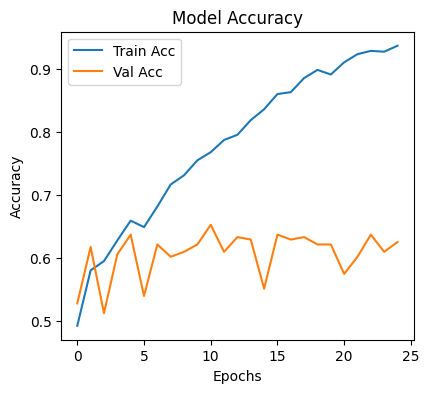

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

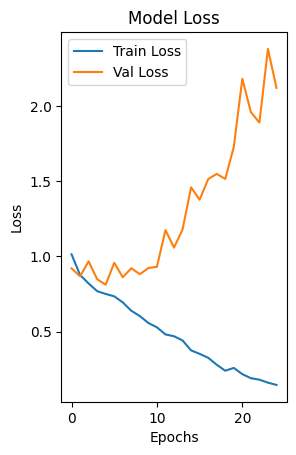

In [39]:
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Differnet Config

In [9]:
cnn = tf.keras.models.Sequential()

cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,1]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Dropout(0.25))

cnn.add(tf.keras.layers.Flatten())

cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))

cnn.add(tf.keras.layers.Dropout(0.4))

cnn.add(tf.keras.layers.Dense(units=3,activation='softmax'))

I0000 00:00:1760941065.029587 1847861 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1760941065.030191 1847861 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [17]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         4,503 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,789,651 (29.72 MB)

 Trainable params: 7,789,651 (29.72 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
training_history = cnn.fit(x=train_gen,validation_data=val_gen,epochs=25)

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 140s 6s/step - accuracy: 0.3469 - loss: 1.0987 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 137s 6s/step - accuracy: 0.3274 - loss: 1.0997 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 139s 6s/step - accuracy: 0.3373 - loss: 1.0988 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 137s 6s/step - accuracy: 0.3851 - loss: 1.0978 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 136s 6s/step - accuracy: 0.2773 - loss: 1.0995 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 137s 6s/step - accuracy: 0.3382 - loss: 1.0988 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 133s 6s/step - accuracy: 0.3455 - loss: 1.0987 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 136s 6s/step - accuracy: 0.3132 - loss: 1.0988 - val_accuracy: 0.3333 - v

In [25]:
val_loss, val_acc = cnn.evaluate(val_gen)
print(f"\nValidation Accuracy: {val_acc*100:.2f}%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.3811 - loss: 1.0985

Validation Accuracy: 33.33%


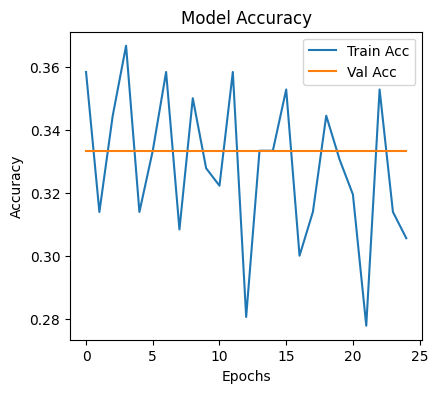

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(training_history.history['accuracy'], label='Train Acc')
plt.plot(training_history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

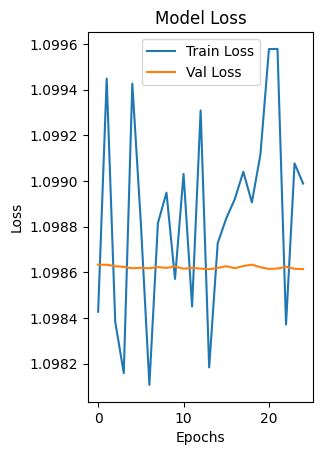

In [28]:
plt.subplot(1,2,2)
plt.plot(training_history.history['loss'], label='Train Loss')
plt.plot(training_history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()